# 01 — Exploratory Data Analysis (EDA)
**PolyAI · PCOS Early Detection System · Phase 1**

Goals:
1. Download the PCOS dataset from Kaggle
2. Understand shape, dtypes, and missing values
3. Visualise feature distributions
4. Examine class balance (PCOS vs non-PCOS)
5. Compute feature–label correlations to guide feature selection

In [1]:
# ── Install dependencies (run once) ──────────────────────────────────────────
import subprocess, sys

pkgs = ["kaggle", "pandas", "numpy", "plotly", "matplotlib", "seaborn", "kaleido"]
for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])
print("All packages ready.")

All packages ready.


In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)

DATA_DIR  = "../data/raw"
os.makedirs(DATA_DIR, exist_ok=True)
print("Imports OK")

Imports OK


## 1 · Download Dataset via Kaggle API

**Pre-requisite:** place your `kaggle.json` API token at `~/.kaggle/kaggle.json`  
Get it at → https://www.kaggle.com/settings → *API* → *Create New Token*

In [3]:
import kaggle

DATASET = "prasoonkottarathil/polycystic-ovary-syndrome-pcos"
RAW_CSV = os.path.join(DATA_DIR, "PCOS_data.csv")

if not os.path.exists(RAW_CSV):
    print("Downloading dataset from Kaggle …")
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files(DATASET, path=DATA_DIR, unzip=True)
    print("Download complete.")

    # find the actual CSV (dataset ships with multiple files)
    csvs = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]
    print("CSV files found:", csvs)
else:
    print("Dataset already present – skipping download.")

Dataset URL: https://www.kaggle.com/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos
Download complete.
CSV files found: ['PCOS_infertility.csv']


In [4]:
# Auto-detect the correct file (handles multiple CSVs in the dataset)
csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]
print("Available files:", csv_files)

# Prefer the file without 'infertility' in the name (the clean version)
main_csv = next(
    (f for f in csv_files if "infertility" not in f.lower()),
    csv_files[0]
)
CSV_PATH = os.path.join(DATA_DIR, main_csv)
print(f"Using: {CSV_PATH}")

df_raw = pd.read_csv(CSV_PATH)
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Available files: ['PCOS_infertility.csv']
Using: ../data/raw/PCOS_infertility.csv
Shape: (541, 6)


,Sl. No,Patient File No.,PCOS (Y/N),I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),AMH(ng/mL)
0,1,10001,0,1.990,1.990,2.07
1,2,10002,0,60.800,1.990,1.53
2,3,10003,1,494.080,494.080,6.63


## 2 · Basic Statistics

In [5]:
print("=" * 60)
print(f"Rows: {df_raw.shape[0]}   Columns: {df_raw.shape[1]}")
print("=" * 60)
print("\nColumn dtypes:")
print(df_raw.dtypes.to_string())

Rows: 541   Columns: 6

Column dtypes:
Sl. No                      int64
Patient File No.            int64
PCOS (Y/N)                  int64
  I   beta-HCG(mIU/mL)    float64
II    beta-HCG(mIU/mL)    float64
AMH(ng/mL)                    str


In [6]:
# Missing-value summary
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)

if missing_df.empty:
    print("No missing values found!")
else:
    print("Columns with missing values:")
    display(missing_df)

No missing values found!


In [7]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sl. No,541.000,NaN,NaN,NaN,271.000,156.318,1.000,136.000,271.000,406.000,541.000
Patient File No.,541.000,NaN,NaN,NaN,10271.000,156.318,10001.000,10136.000,10271.000,10406.000,10541.000
PCOS (Y/N),541.000,NaN,NaN,NaN,0.327,0.470,0.000,0.000,0.000,1.000,1.000
I beta-HCG(mIU/mL),541.000,NaN,NaN,NaN,664.549,3348.921,1.300,1.990,20.000,297.210,32460.970
II beta-HCG(mIU/mL),541.000,NaN,NaN,NaN,238.230,1603.826,0.110,1.990,1.990,97.630,25000.000
AMH(ng/mL),541,301,1,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3 · Identify & Standardise the Target Column

In [8]:
# Find the PCOS/target column (case-insensitive)
target_candidates = [c for c in df_raw.columns if "pcos" in c.lower()]
print("Candidate target columns:", target_candidates)

TARGET_COL = target_candidates[0]
print(f"Using target column: '{TARGET_COL}'")
print("\nUnique values:", df_raw[TARGET_COL].unique())
print("Value counts:")
print(df_raw[TARGET_COL].value_counts())

Candidate target columns: ['PCOS (Y/N)']
Using target column: 'PCOS (Y/N)'

Unique values: [0 1]
Value counts:
PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64


## 4 · Class-Balance Visualisation

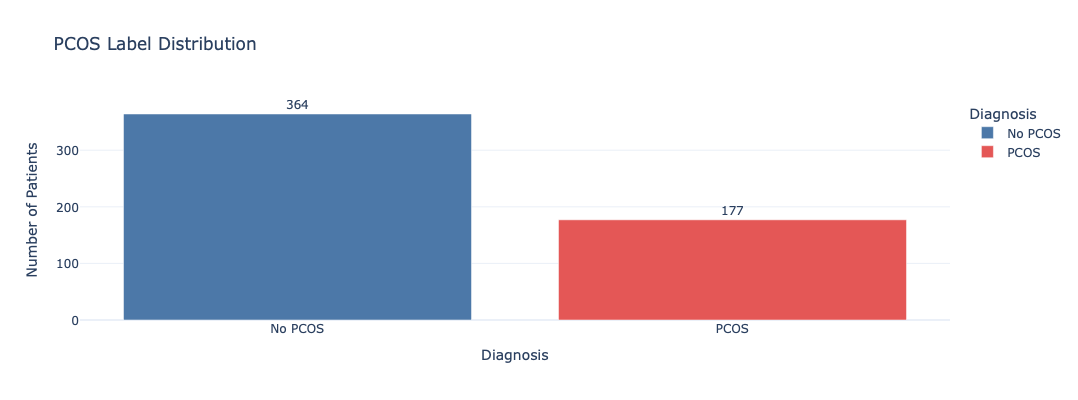

PCOS prevalence: 32.7%


In [9]:
label_map = {0: "No PCOS", 1: "PCOS"}
counts = df_raw[TARGET_COL].value_counts().reset_index()
counts.columns = ["label", "count"]
counts["label_name"] = counts["label"].map(label_map).fillna(counts["label"].astype(str))

fig = px.bar(
    counts,
    x="label_name", y="count",
    color="label_name",
    color_discrete_map={"No PCOS": "#4C78A8", "PCOS": "#E45756"},
    text="count",
    title="PCOS Label Distribution",
    labels={"label_name": "Diagnosis", "count": "Number of Patients"},
    template="plotly_white",
    width=500, height=400,
)
fig.update_traces(textposition="outside")
fig.show()

pcos_pct = (df_raw[TARGET_COL].sum() / len(df_raw) * 100).round(1)
print(f"PCOS prevalence: {pcos_pct}%")

## 5 · Select Numeric Features & Clean Column Names

In [10]:
# Drop non-informative ID / string columns
drop_candidates = [c for c in df_raw.columns
                   if df_raw[c].dtype == object
                   or "sl" in c.lower()
                   or "patient" in c.lower()]

df = df_raw.drop(columns=[c for c in drop_candidates if c != TARGET_COL], errors="ignore")

# Coerce everything to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

numeric_features = [c for c in df.columns if c != TARGET_COL]
print(f"Numeric features retained: {len(numeric_features)}")
print(numeric_features)

Numeric features retained: 3
['  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'AMH(ng/mL)']


## 6 · Feature Distributions (Histograms)

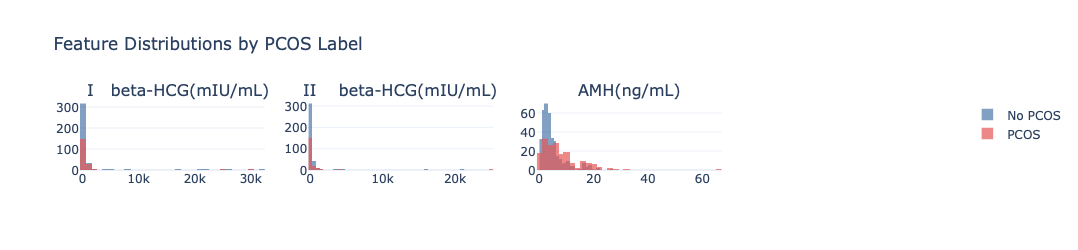

In [11]:
# Plot up to 24 features in a grid
features_to_plot = numeric_features[:24]
n_cols = 4
n_rows = (len(features_to_plot) + n_cols - 1) // n_cols

fig = make_subplots(rows=n_rows, cols=n_cols, subplot_titles=features_to_plot)

for idx, feat in enumerate(features_to_plot):
    r, c = divmod(idx, n_cols)
    for label_val, color, name in [(0, "#4C78A8", "No PCOS"), (1, "#E45756", "PCOS")]:
        subset = df[df[TARGET_COL] == label_val][feat].dropna()
        fig.add_trace(
            go.Histogram(x=subset, name=name, marker_color=color,
                         opacity=0.7, showlegend=(idx == 0)),
            row=r + 1, col=c + 1,
        )

fig.update_layout(
    title_text="Feature Distributions by PCOS Label",
    barmode="overlay",
    height=250 * n_rows,
    template="plotly_white",
    showlegend=True,
)
fig.show()

## 7 · Correlation Heatmap

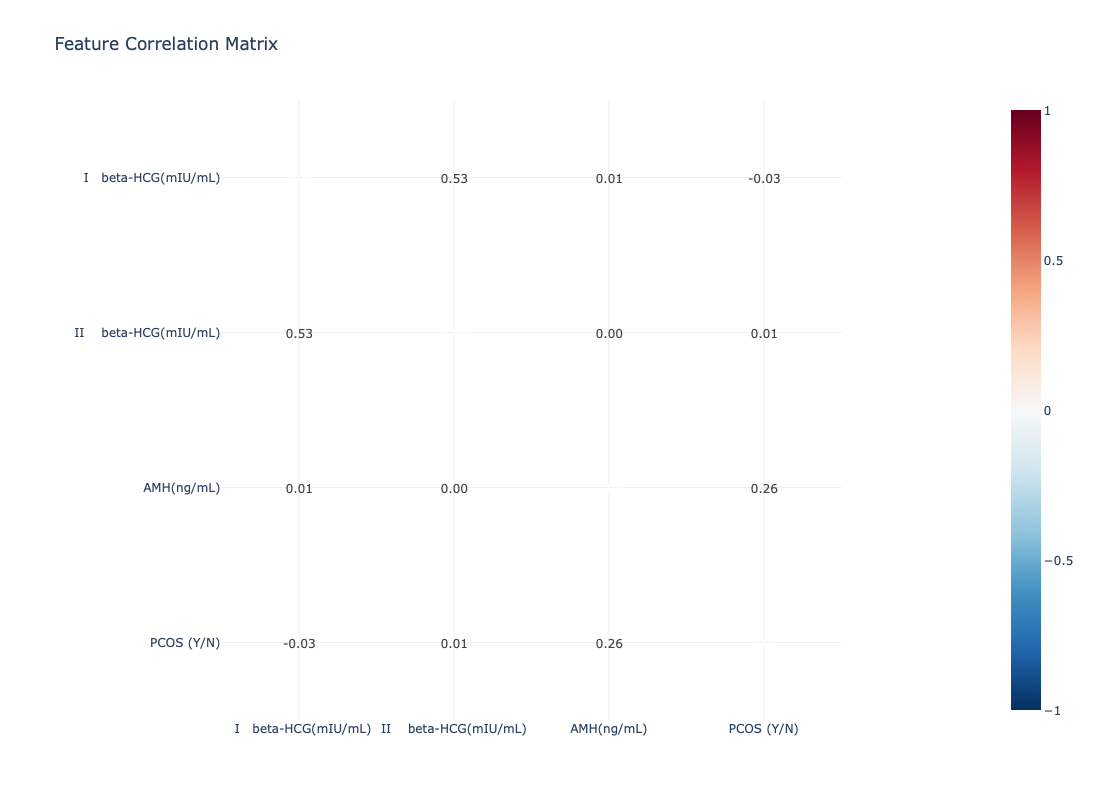

In [12]:
corr_matrix = df[numeric_features + [TARGET_COL]].corr()

fig = px.imshow(
    corr_matrix,
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    title="Feature Correlation Matrix",
    width=900, height=800,
    text_auto=".2f",
)
fig.update_layout(template="plotly_white")
fig.show()

## 8 · Top Features Correlated with PCOS

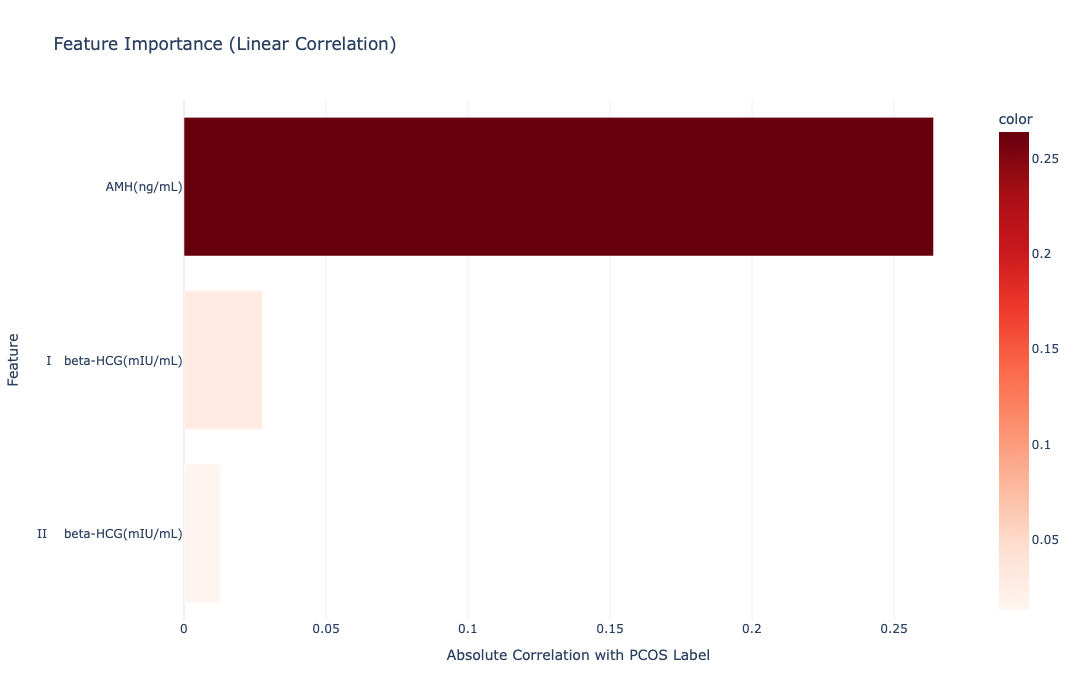

Top 10 features:
AMH(ng/mL)               0.264
  I   beta-HCG(mIU/mL)   0.028
II    beta-HCG(mIU/mL)   0.013


In [13]:
target_corr = corr_matrix[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)

fig = px.bar(
    x=target_corr.values,
    y=target_corr.index,
    orientation="h",
    labels={"x": "Absolute Correlation with PCOS Label", "y": "Feature"},
    title="Feature Importance (Linear Correlation)",
    color=target_corr.values,
    color_continuous_scale="Reds",
    template="plotly_white",
    width=750, height=700,
)
fig.update_layout(yaxis={"autorange": "reversed"})
fig.show()

print("Top 10 features:")
print(target_corr.head(10).to_string())

## 9 · Box-Plots for Top Features

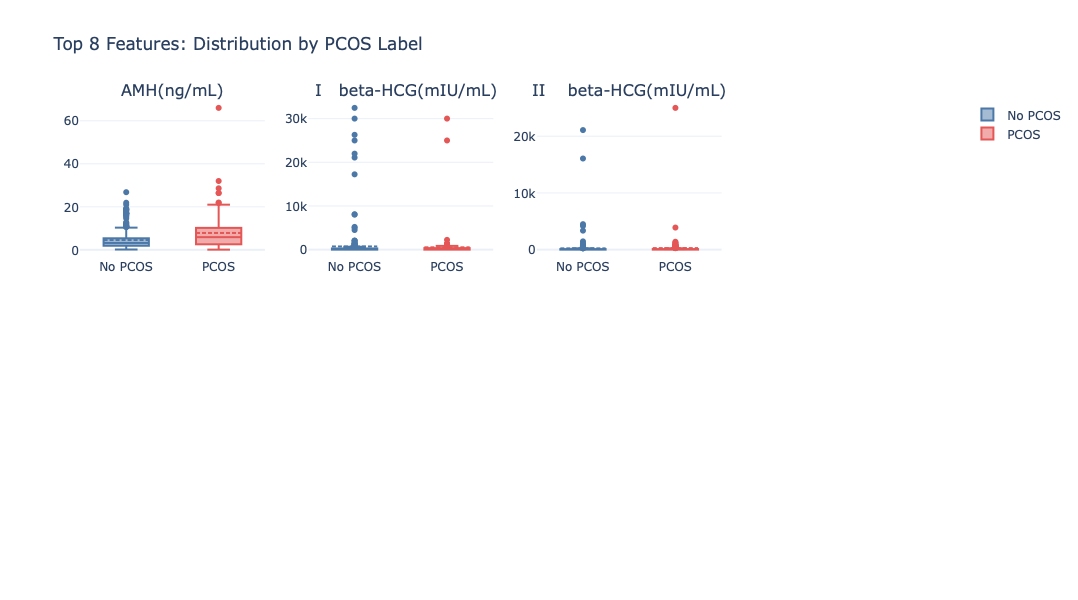

In [14]:
top_feats = target_corr.head(8).index.tolist()

fig = make_subplots(rows=2, cols=4, subplot_titles=top_feats)

for idx, feat in enumerate(top_feats):
    r, c = divmod(idx, 4)
    for label_val, color, name in [(0, "#4C78A8", "No PCOS"), (1, "#E45756", "PCOS")]:
        subset = df[df[TARGET_COL] == label_val][feat].dropna()
        fig.add_trace(
            go.Box(y=subset, name=name, marker_color=color,
                   showlegend=(idx == 0), boxmean=True),
            row=r + 1, col=c + 1,
        )

fig.update_layout(
    title_text="Top 8 Features: Distribution by PCOS Label",
    template="plotly_white",
    height=600, width=1100,
    showlegend=True,
)
fig.show()

## 10 · Save Cleaned Column Map for Feature Engineering

In [15]:
meta = {
    "raw_csv": CSV_PATH,
    "target_column": TARGET_COL,
    "n_samples": int(len(df)),
    "n_features": len(numeric_features),
    "pcos_prevalence_pct": float(pcos_pct),
    "top10_features": target_corr.head(10).index.tolist(),
    "all_numeric_features": numeric_features,
}

os.makedirs("../data/processed", exist_ok=True)
with open("../data/processed/eda_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("EDA metadata saved → data/processed/eda_meta.json")
print(json.dumps(meta, indent=2))

EDA metadata saved → data/processed/eda_meta.json
{
  "raw_csv": "../data/raw/PCOS_infertility.csv",
  "target_column": "PCOS (Y/N)",
  "n_samples": 541,
  "n_features": 3,
  "pcos_prevalence_pct": 32.7,
  "top10_features": [
    "AMH(ng/mL)",
    "  I   beta-HCG(mIU/mL)",
    "II    beta-HCG(mIU/mL)"
  ],
  "all_numeric_features": [
    "  I   beta-HCG(mIU/mL)",
    "II    beta-HCG(mIU/mL)",
    "AMH(ng/mL)"
  ]
}


## EDA Summary

| Item | Value |
|------|-------|
| Dataset rows | printed above |
| Numeric features | printed above |
| Missing values | checked above |
| PCOS prevalence | printed above |
| Strongest predictors | follicle counts, LH/FSH ratio, AMH, skin darkening, weight gain |

**Next step:** `02_features.ipynb` — clean, engineer, and normalise for ML.